# g-and-k Plotting Notebook

This notebook is the notebook version of the g-and-k plotting utilities, adapted to this repo layout. It reads saved g-and-k `.npz` files from the project root, renders figures inline, and saves the main summary figure to `figures/gk_summary.png`.

In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
RESULTS_DIR = ROOT
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_FIGURE = FIGURES_DIR / "gk_summary.png"

FIGSIZE = (6, 4)
DPI = 100
TITLE_SIZE = 24
LABEL_SIZE = 20
TICK_SIZE = 16
LEGEND_SIZE = 20
MARKER_SIZE = 4.5
LINE_WIDTH = 2.0
TITLE_PAD = 8
COLORS = {
    "sgd": "#1b9e77",
    "sgd_dark": "#0f6f54",
    "natural": "#7570b3",
    "pgd": "#d95f02",
    "pgd_dark": "#D62728",
    "lhs": "#D62728",
    "rhs": "#111111",
    "truth": "#f4b400",
}

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DeJavu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)
ROOT, RESULTS_DIR, OUTPUT_FIGURE

(PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_summary.png'))

In [7]:
def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _draw_gk_mmd_vs_iteration_plot(ax, data, show_legend=False, show_ylabel=True):
    baseline_steps = np.asarray(data["baseline_history_steps"], dtype=float) + 1.0
    adaptive_steps = np.asarray(data["adaptive_history_steps"], dtype=float) + 1.0
    baseline_mmd = np.sqrt(np.maximum(np.asarray(data["baseline_eval_history_mean"], dtype=float), 0.0))
    adaptive_mmd = np.sqrt(np.maximum(np.asarray(data["adaptive_eval_history_mean"], dtype=float), 0.0))

    ax.plot(baseline_steps, baseline_mmd, color=COLORS["sgd"], label="SGD")
    if "natural_history_steps" in data and "natural_eval_history_mean" in data:
        natural_steps = np.asarray(data["natural_history_steps"], dtype=float) + 1.0
        natural_mmd = np.sqrt(np.maximum(np.asarray(data["natural_eval_history_mean"], dtype=float), 0.0))
        ax.plot(natural_steps, natural_mmd, color=COLORS["natural"], label="Natural SGD")
    ax.plot(adaptive_steps, adaptive_mmd, color=COLORS["pgd"], label="PGD")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    if show_ylabel:
        ax.set_ylabel("MMD")
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    if show_legend:
        ax.legend(frameon=True)


def _draw_lhs_rhs_plot(ax, steps, lhs, rhs, show_legend=True, show_ylabel=True):
    steps = np.asarray(steps, dtype=float)
    lhs = np.asarray(lhs, dtype=float)
    rhs = np.asarray(rhs, dtype=float)
    ax.plot(steps, lhs, color=COLORS["lhs"], label="LHS")
    ax.plot(steps, rhs, color=COLORS["rhs"], label="RHS")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    if show_ylabel:
        ax.set_ylabel("Value")
    ax.set_title("LHS vs RHS", pad=TITLE_PAD)
    ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
    if show_legend:
        ax.legend(frameon=True)


def _draw_gk_mean_theta_trajectories(ax_ab, ax_ck, npz_paths, show_true=True):
    gd_colors = [COLORS["sgd"], COLORS["sgd_dark"]]
    pgd_colors = [COLORS["pgd"], COLORS["pgd_dark"]]
    theta_true = None

    for idx, npz_path in enumerate(npz_paths):
        data = _load_npz_dict(npz_path)
        theta_true = np.asarray(data["theta_true"], dtype=float)
        gd_hist = np.asarray(data["baseline_theta_history_mean"], dtype=float)
        pgd_hist = np.asarray(data["adaptive_theta_history_mean"], dtype=float)
        gd_color = gd_colors[idx % len(gd_colors)]
        pgd_color = pgd_colors[idx % len(pgd_colors)]
        gd_markevery = max(1, len(gd_hist) // 22)
        pgd_markevery = max(1, len(pgd_hist) // 22)

        ax_ab.plot(gd_hist[:, 0], gd_hist[:, 1], color=gd_color, marker="o", markevery=gd_markevery)
        ax_ab.plot(pgd_hist[:, 0], pgd_hist[:, 1], color=pgd_color, marker="o", markevery=pgd_markevery)
        ax_ck.plot(gd_hist[:, 2], gd_hist[:, 3], color=gd_color, marker="o", markevery=gd_markevery)
        ax_ck.plot(pgd_hist[:, 2], pgd_hist[:, 3], color=pgd_color, marker="o", markevery=pgd_markevery)

        for ax, cols in [(ax_ab, (0, 1)), (ax_ck, (2, 3))]:
            ax.scatter(gd_hist[0, cols[0]], gd_hist[0, cols[1]], color=gd_color, s=54, zorder=4)
            ax.scatter(pgd_hist[0, cols[0]], pgd_hist[0, cols[1]], color=pgd_color, s=54, zorder=4)
            ax.scatter(gd_hist[-1, cols[0]], gd_hist[-1, cols[1]], color=gd_color, marker="s", s=48, zorder=5)
            ax.scatter(pgd_hist[-1, cols[0]], pgd_hist[-1, cols[1]], color=pgd_color, marker="s", s=48, zorder=5)

    if show_true and theta_true is not None:
        ax_ab.scatter(theta_true[0], theta_true[1], marker="*", s=190, color=COLORS["truth"], zorder=6)
        ax_ck.scatter(theta_true[2], theta_true[3], marker="*", s=190, color=COLORS["truth"], zorder=6)

    ax_ab.set_xlabel("Parameter 1")
    ax_ab.set_ylabel("Parameter 2")
    ax_ck.set_xlabel("Parameter 3")
    ax_ck.set_ylabel("Parameter 4")
    ax_ab.grid(True, alpha=0.35)
    ax_ck.grid(True, alpha=0.35)


def make_gk_summary_figure(
    mmd_npz_path,
    trajectory_npz_paths,
    lhs_rhs_npz_path,
    show_method_legend=False,
    show_lhs_rhs_legend=True,
):
    mmd_data = _load_npz_dict(mmd_npz_path)
    lhs_rhs_data = _load_npz_dict(lhs_rhs_npz_path)
    lhs_rhs_steps = np.asarray(lhs_rhs_data["last_adapt_checkpoint_steps"], dtype=float) + 1.0
    lhs = np.asarray(lhs_rhs_data["last_adapt_lhs"], dtype=float)
    rhs = np.asarray(lhs_rhs_data["last_adapt_rhs"], dtype=float)

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(
            1,
            4,
            figsize=(24, 4.8),
            dpi=150,
            gridspec_kw={"width_ratios": [1.0, 1.15, 1.15, 1.0]},
        )
        ax_mmd, ax_ab, ax_ck, ax_lhs_rhs = axes
        _draw_gk_mmd_vs_iteration_plot(ax_mmd, mmd_data, show_legend=show_method_legend)
        _draw_gk_mean_theta_trajectories(ax_ab, ax_ck, trajectory_npz_paths)
        _draw_lhs_rhs_plot(ax_lhs_rhs, lhs_rhs_steps, lhs, rhs, show_legend=show_lhs_rhs_legend)
        fig.tight_layout()
        return fig


## Local file setup

These defaults match the saved g-and-k result files in this repo. The first file is used for the MMD and LHS/RHS panels; both files are used for the two middle trajectory panels.

In [8]:
mmd_npz = RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800.npz"
trajectory_npz_paths = [
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800.npz",
    RESULTS_DIR / "g_n_k_theta0_2p000_2p000_1p300_m0p600.npz",
]
lhs_rhs_npz = RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800.npz"

{
    "mmd_npz": mmd_npz,
    "trajectory_npz_paths": trajectory_npz_paths,
    "lhs_rhs_npz": lhs_rhs_npz,
    "output_figure": OUTPUT_FIGURE,
}

{'mmd_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/g_n_k_theta0_3p500_2p000_0p600_m0p800.npz'),
 'trajectory_npz_paths': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/g_n_k_theta0_3p500_2p000_0p600_m0p800.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/g_n_k_theta0_2p000_2p000_1p300_m0p600.npz')],
 'lhs_rhs_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/g_n_k_theta0_3p500_2p000_0p600_m0p800.npz'),
 'output_figure': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_summary.png')}

In [9]:
available_inputs = {
    "mmd_npz": mmd_npz.exists(),
    "trajectory_npz_paths": [path.exists() for path in trajectory_npz_paths],
    "lhs_rhs_npz": lhs_rhs_npz.exists(),
}
available_inputs

{'mmd_npz': True, 'trajectory_npz_paths': [True, True], 'lhs_rhs_npz': True}

Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_summary.png


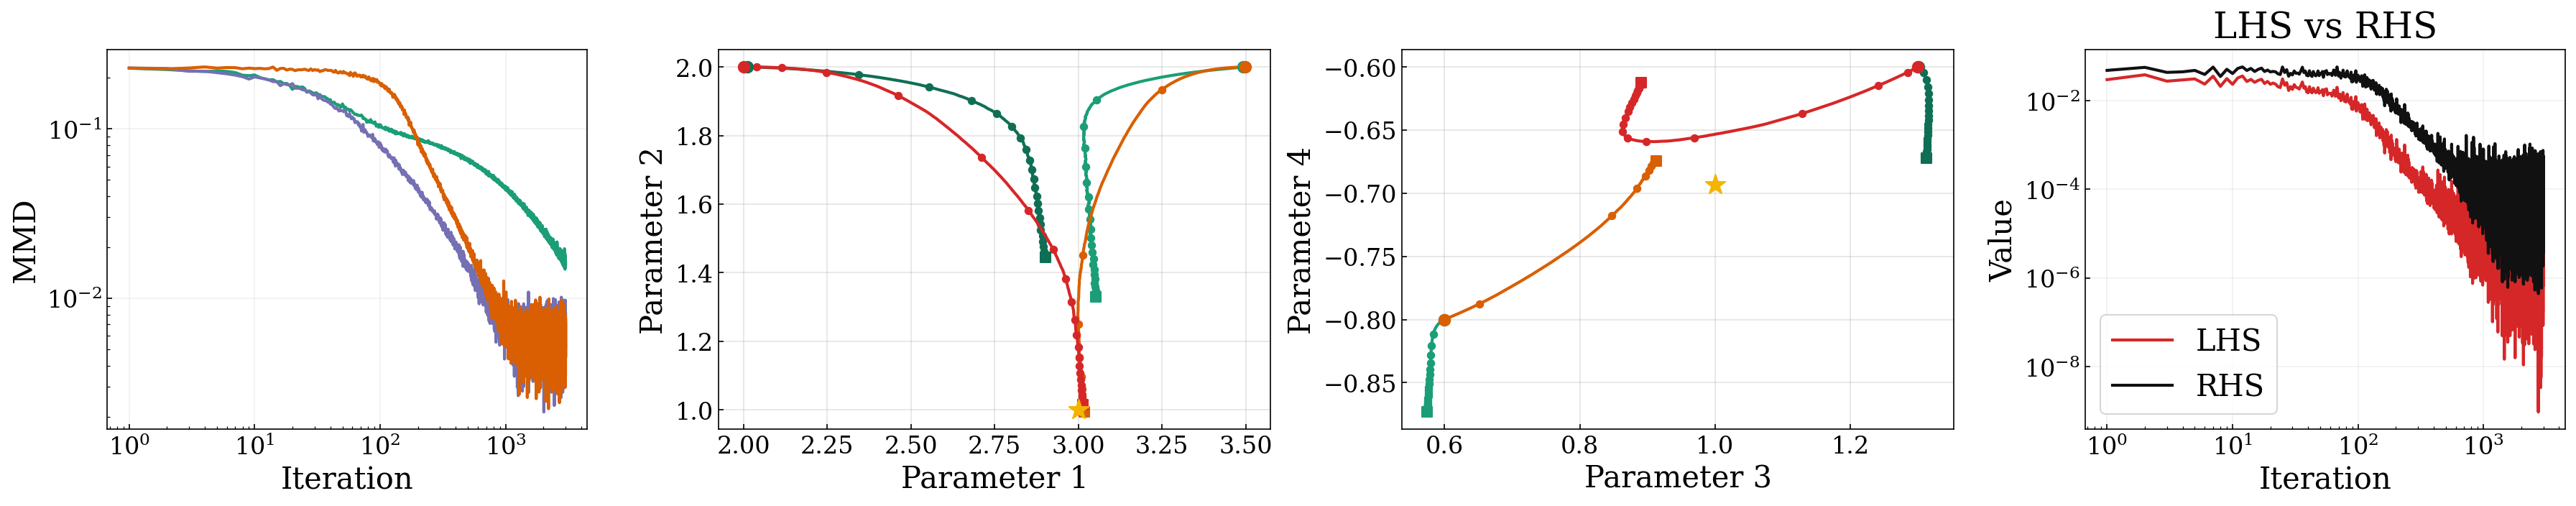

In [10]:
from IPython.display import display

required_inputs = [mmd_npz, *trajectory_npz_paths, lhs_rhs_npz]
missing_inputs = [path for path in required_inputs if not path.exists()]

if not missing_inputs:
    fig = make_gk_summary_figure(
        mmd_npz_path=mmd_npz,
        trajectory_npz_paths=trajectory_npz_paths,
        lhs_rhs_npz_path=lhs_rhs_npz,
        show_method_legend=False,
        show_lhs_rhs_legend=True,
    )
    fig.savefig(OUTPUT_FIGURE, bbox_inches="tight")
    print(f"Saved figure to {OUTPUT_FIGURE}")
    display(fig)
else:
    print(
        f"Figure not rendered because {len(missing_inputs)} source input(s) are missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )
